In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("/content/telco_customer_churn_cleaned.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup,MonthlyRevenue,RevenuePerTenureMonth
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0-6 Months,29.85,29.850000
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,No,One year,No,Mailed check,56.95,1889.50,0,25-48 Months,56.95,55.573529
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,0-6 Months,53.85,54.075000
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,25-48 Months,42.30,40.905556
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,0-6 Months,70.70,75.825000


In [3]:
features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "Contract",
    "InternetService",
    "PaymentMethod",
    "TechSupport",
    "OnlineSecurity",
    "PaperlessBilling"
]

X = df[features]
y = df["Churn"]

one-hot encoding

In [4]:
X = pd.get_dummies(X, drop_first=True)

In [5]:
X.head()

,tenure,MonthlyCharges,TotalCharges,Contract_One year,Contract_Two year,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TechSupport_No internet service,TechSupport_Yes,OnlineSecurity_No internet service,OnlineSecurity_Yes,PaperlessBilling_Yes
0,1,29.85,29.85,False,False,False,False,False,True,False,False,False,False,False,True
1,34,56.95,1889.50,True,False,False,False,False,False,True,False,False,False,True,False
2,2,53.85,108.15,False,False,False,False,False,False,True,False,False,False,True,True
3,45,42.30,1840.75,True,False,False,False,False,False,False,False,True,False,True,False
4,2,70.70,151.65,False,False,True,False,False,True,False,False,False,False,False,True


80-20 train test split

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model training

In [7]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

  MODEL METRICS

In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("Precision:", round(precision_score(y_test, y_pred), 3))
print("Recall:", round(recall_score(y_test, y_pred), 3))
print("F1 Score:", round(f1_score(y_test, y_pred), 3))

Accuracy: 0.8
Precision: 0.648
Recall: 0.537
F1 Score: 0.588


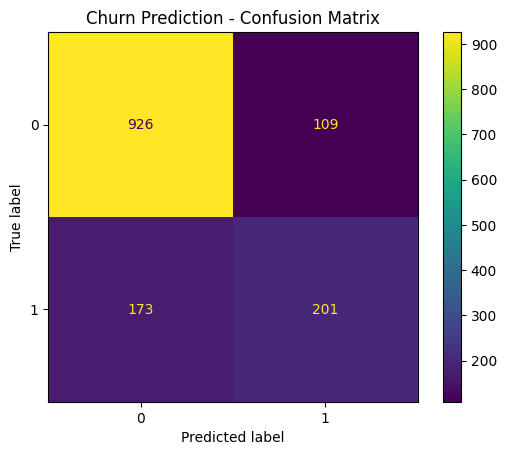

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Churn Prediction - Confusion Matrix")
plt.show()

In [10]:
df["ChurnProbability"] = model.predict_proba(X)[:, 1]

In [11]:
df["RiskLevel"] = pd.cut(
    df["ChurnProbability"],
    bins=[0, 0.3, 0.6, 1],
    labels=["Low", "Medium", "High"]
)

In [12]:
df["RevenueAtRisk"] = df["MonthlyCharges"] * df["ChurnProbability"]

In [13]:
risk_data = df[
    [
        "customerID",
        "tenure",
        "Contract",
        "MonthlyCharges",
        "TotalCharges",
        "ChurnProbability",
        "RiskLevel",
        "RevenueAtRisk",
        "Churn"
    ]
]

In [14]:
risk_data = risk_data.sort_values(
    "ChurnProbability",
    ascending=False
)

In [15]:
risk_data.head(10)

,customerID,tenure,Contract,MonthlyCharges,TotalCharges,ChurnProbability,RiskLevel,RevenueAtRisk,Churn
6482,5419-JPRRN,1,Month-to-month,101.45,101.45,0.773926,High,78.514839,1
2208,7216-EWTRS,1,Month-to-month,100.80,100.80,0.773406,High,77.959339,1
1704,0107-YHINA,1,Month-to-month,99.75,99.75,0.772564,High,77.063245,1
6894,1400-MMYXY,3,Month-to-month,105.90,334.65,0.770375,High,81.582667,1
6866,0295-PPHDO,1,Month-to-month,95.45,95.45,0.769091,High,73.409781,1
3380,5178-LMXOP,1,Month-to-month,95.10,95.10,0.768807,High,73.113565,1
2577,4910-GMJOT,1,Month-to-month,94.60,94.60,0.768401,High,72.690706,1
4800,9300-AGZNL,1,Month-to-month,94.00,94.00,0.767912,High,72.183748,1
3209,8149-RSOUN,1,Month-to-month,93.85,93.85,0.767790,High,72.057090,1
5933,6496-SLWHQ,3,Month-to-month,105.00,294.45,0.767648,High,80.603051,1


In [16]:
risk_data.to_csv(
    "/content/customer_churn_risk.csv",
    index=False
)
from google.colab import files

files.download("/content/customer_churn_risk.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

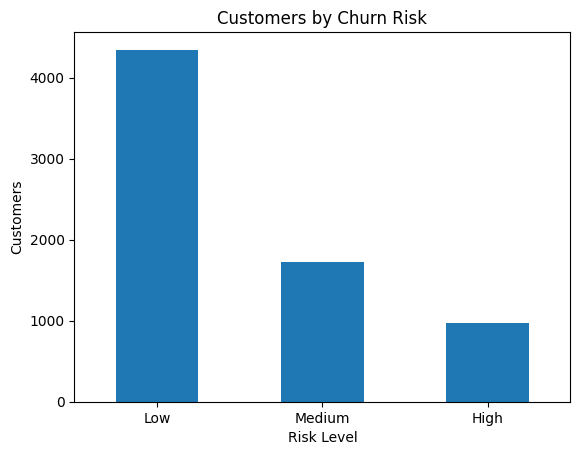

In [17]:
risk_data["RiskLevel"].value_counts().plot(kind="bar")

plt.title("Customers by Churn Risk")
plt.xlabel("Risk Level")
plt.ylabel("Customers")
plt.xticks(rotation=0)
plt.show()

In [18]:
df.to_csv("/content/tableau_customer_churn.csv", index=False)

In [19]:
from google.colab import files
files.download("/content/tableau_customer_churn.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>